In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
PROJECT_ROOT = Path.cwd().parent

ratings_path = PROJECT_ROOT / "data" / "interim" / "ratings.csv"
movies_path = PROJECT_ROOT / "data" / "interim" / "movies.csv"

ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)

print("Ratings:", ratings.shape)
print("Movies:", movies.shape)

Ratings: (100000, 4)
Movies: (1682, 5)


In [3]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
movies.head()

,movie_id,title,release_date,video_release_date,imdb_url
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995)


In [5]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            1682 non-null   int64  
 1   title               1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   imdb_url            1679 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 65.8+ KB


In [7]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            1682 non-null   int64  
 1   title               1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   imdb_url            1679 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 65.8+ KB


In [8]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            1682 non-null   int64  
 1   title               1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   imdb_url            1679 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 65.8+ KB


In [9]:
print("Users:", ratings["user_id"].nunique())
print("Movies:", ratings["movie_id"].nunique())
print("Ratings:", len(ratings))
print("Minimum rating:", ratings["rating"].min())
print("Maximum rating:", ratings["rating"].max())
print("Average rating:", round(ratings["rating"].mean(), 2))

Users: 943
Movies: 1682
Ratings: 100000
Minimum rating: 1
Maximum rating: 5
Average rating: 3.53


### Rating distribution

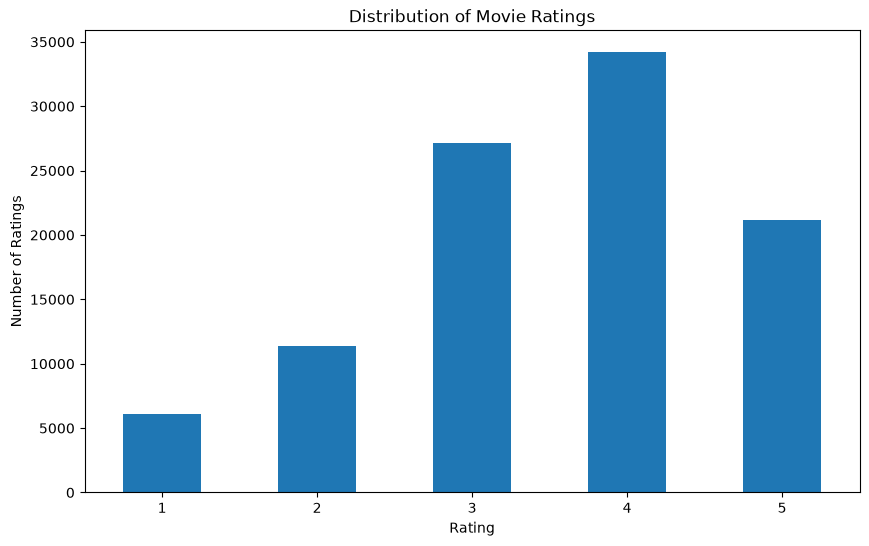

In [10]:
rating_counts = ratings["rating"].value_counts().sort_index()

rating_counts.plot(kind="bar")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.show()

### Analyze user activity

In [11]:
user_activity = ratings.groupby("user_id").size()

print(user_activity.describe())

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64


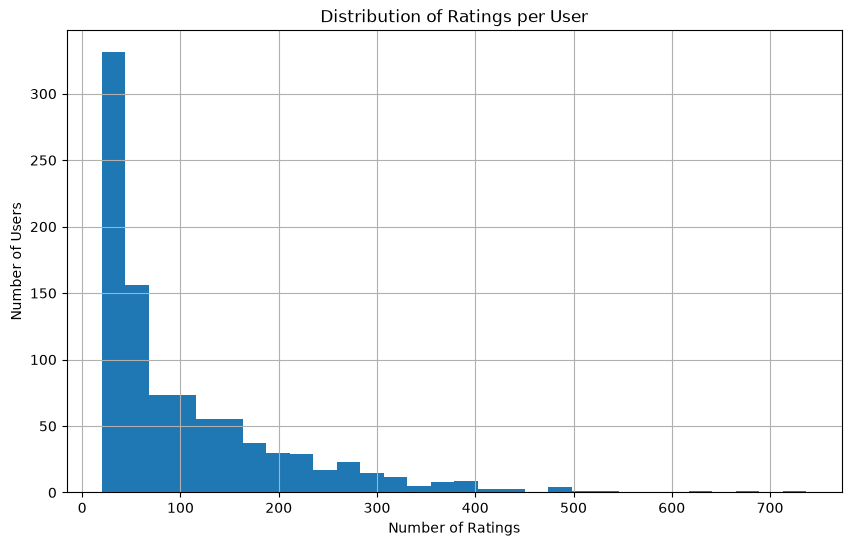

In [12]:
user_activity.hist(bins=30)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

### Analyze movie popularity

In [13]:
movie_popularity = (
    ratings.groupby("movie_id")
    .size()
    .sort_values(ascending=False)
)

movie_popularity.describe()

count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
dtype: float64

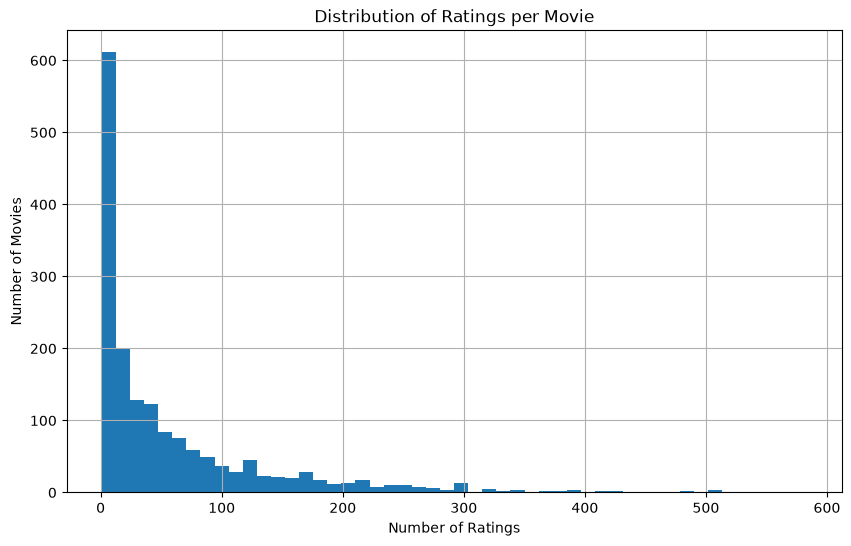

In [14]:
movie_popularity.hist(bins=50)

plt.title("Distribution of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

### The Most Rated Movie 

In [15]:
movie_stats = (
    ratings.groupby("movie_id")
    .agg(
        rating_count=("rating", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[["movie_id", "title"]],
    on="movie_id",
    how="left"
)

In [16]:
movie_stats.sort_values(
    "rating_count",
    ascending=False
).head(10)

,movie_id,rating_count,average_rating,title
49,50,583,4.358491,Star Wars (1977)
257,258,509,3.803536,Contact (1997)
99,100,508,4.155512,Fargo (1996)
180,181,507,4.007890,Return of the Jedi (1983)
293,294,485,3.156701,Liar Liar (1997)
285,286,481,3.656965,"English Patient, The (1996)"
287,288,478,3.441423,Scream (1996)
0,1,452,3.878319,Toy Story (1995)
299,300,431,3.631090,Air Force One (1997)
120,121,429,3.438228,Independence Day (ID4) (1996)


### Find the most-rated movies

In [17]:
movie_stats = (
    ratings.groupby("movie_id")
    .agg(
        rating_count=("rating", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[["movie_id", "title"]],
    on="movie_id",
    how="left"
)

In [18]:
movie_stats.sort_values(
    "rating_count",
    ascending=False
).head(10)

,movie_id,rating_count,average_rating,title
49,50,583,4.358491,Star Wars (1977)
257,258,509,3.803536,Contact (1997)
99,100,508,4.155512,Fargo (1996)
180,181,507,4.007890,Return of the Jedi (1983)
293,294,485,3.156701,Liar Liar (1997)
285,286,481,3.656965,"English Patient, The (1996)"
287,288,478,3.441423,Scream (1996)
0,1,452,3.878319,Toy Story (1995)
299,300,431,3.631090,Air Force One (1997)
120,121,429,3.438228,Independence Day (ID4) (1996)


### Find highly rated movies

In [19]:
popular_enough = movie_stats[
    movie_stats["rating_count"] >= 50
]

popular_enough.sort_values(
    "average_rating",
    ascending=False
).head(10)

,movie_id,rating_count,average_rating,title
407,408,112,4.491071,"Close Shave, A (1995)"
317,318,298,4.466443,Schindler's List (1993)
168,169,118,4.466102,"Wrong Trousers, The (1993)"
482,483,243,4.456790,Casablanca (1942)
113,114,67,4.447761,Wallace & Gromit: The Best of Aardman Animatio...
63,64,283,4.445230,"Shawshank Redemption, The (1994)"
602,603,209,4.387560,Rear Window (1954)
11,12,267,4.385768,"Usual Suspects, The (1995)"
49,50,583,4.358491,Star Wars (1977)
177,178,125,4.344000,12 Angry Men (1957)


In [20]:
### Calculate sparsity

n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
n_interactions = len(ratings)

possible_interactions = n_users * n_movies

sparsity = 1 - (
    n_interactions / possible_interactions
)

print(f"Users: {n_users:,}")
print(f"Movies: {n_movies:,}")
print(f"Possible interactions: {possible_interactions:,}")
print(f"Actual interactions: {n_interactions:,}")
print(f"Sparsity: {sparsity:.2%}")

Users: 943
Movies: 1,682
Possible interactions: 1,586,126
Actual interactions: 100,000
Sparsity: 93.70%
